# Predicting Customer Churn
**`Playground Series - Season 6 Episode 3`**

**GOAL:** Predict the likelihood of customer churn.

## Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

In [3]:
# Import custom modules
from Scripts.plot_charts import (
    plot_bar_counts, plot_bar_percentages,
    plot_hist_counts, plot_hist_percentages,
    plot_box_by_target,
    plot_stacked_bar_by_target, plot_grouped_bar_by_target
)

## Read Dataset

In [4]:
train_df = pd.read_csv("../Data/train.csv")
test_df = pd.read_csv("../Data/test.csv")

## Data Sanity Checks

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  object 
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  object 
 4   Dependents        254655 non-null  object 
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  object 
 7   MultipleLines     254655 non-null  object 
 8   InternetService   254655 non-null  object 
 9   OnlineSecurity    254655 non-null  object 
 10  OnlineBackup      254655 non-null  object 
 11  DeviceProtection  254655 non-null  object 
 12  TechSupport       254655 non-null  object 
 13  StreamingTV       254655 non-null  object 
 14  StreamingMovies   254655 non-null  object 
 15  Contract          254655 non-null  object 
 16  PaperlessBilling  25

**`Observation`**
- Both training and test dataset contains no missing values, as all `594,194 entries` across the `21 columns` have non-null counts. This indicates that the datasets are clean and does not require any imputation or missing value handling.
- The datasets consist of `16 Categorical` features and `4 Numerical` feature, indicating that appropriate encoding techniques will be required to convert categorical variables into a numerical format before training machine learning models.

In [7]:
train_df.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [8]:
test_df.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,254655.000000,254655.00000,254655.000000,254655.000000,254655.000000
mean,721521.000000,0.11362,37.279716,66.130803,2544.617351
std,73512.710738,0.31735,24.777625,31.104139,2348.124379
min,594194.000000,0.00000,1.000000,18.300000,18.800000
25%,657857.500000,0.00000,13.000000,30.150000,677.625000
50%,721521.000000,0.00000,36.000000,74.350000,1468.750000
75%,785184.500000,0.00000,62.000000,91.100000,4317.300000
max,848848.000000,1.00000,72.000000,118.750000,8684.800000


**`Observation`**
- The statistical summaries of the numerical features in the training and test datasets are nearly identical, indicating that both datasets follow a similar distribution. This suggests that the test data is drawn from the same population as the training data, reducing the risk of data drift and improving the reliability of model evaluation.

## Standardize Dataframe Columns

In [9]:
train_df.columns = [
    col.upper() for col in train_df.columns
]

test_df.columns = [
    col.upper() for col in test_df.columns
]

column_change_dict = {
    "SENIORCITIZEN": "SENIOR_CITIZEN",
    "PHONESERVICE": "PHONE_SERVICE",
    "MULTIPLELINES": "MULTIPLE_LINES",
    "INTERNETSERVICE": "INTERNET_SERVICE",
    "ONLINESECURITY": "ONLINE_SECURITY",
    "ONLINEBACKUP": "ONLINE_BACKUP",
    "DEVICEPROTECTION": "DEVICE_PROTECTION",
    "TECHSUPPORT": "TECH_SUPPORT",
    "STREAMINGTV": "STREAMING_TV",
    "STREAMINGMOVIES": "STREAMING_MOVIES",
    "PAPERLESSBILLING": "PAPERLESS_BILLING",
    "PAYMENTMETHOD": "PAYMENT_METHOD",
    "MONTHLYCHARGES": "MONTHLY_CHARGES",
    "TOTALCHARGES": "TOTAL_CHARGES"
}

train_df.rename(
    columns = column_change_dict, inplace = True
)

test_df.rename(
    columns = column_change_dict, inplace = True
)

In [10]:
train_df.head()

,ID,GENDER,SENIOR_CITIZEN,PARTNER,DEPENDENTS,TENURE,PHONE_SERVICE,MULTIPLE_LINES,INTERNET_SERVICE,ONLINE_SECURITY,...,DEVICE_PROTECTION,TECH_SUPPORT,STREAMING_TV,STREAMING_MOVIES,CONTRACT,PAPERLESS_BILLING,PAYMENT_METHOD,MONTHLY_CHARGES,TOTAL_CHARGES,CHURN
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [11]:
test_df.head()

,ID,GENDER,SENIOR_CITIZEN,PARTNER,DEPENDENTS,TENURE,PHONE_SERVICE,MULTIPLE_LINES,INTERNET_SERVICE,ONLINE_SECURITY,ONLINE_BACKUP,DEVICE_PROTECTION,TECH_SUPPORT,STREAMING_TV,STREAMING_MOVIES,CONTRACT,PAPERLESS_BILLING,PAYMENT_METHOD,MONTHLY_CHARGES,TOTAL_CHARGES
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


## Data Sanity Checks
- No inspection needed for columns:
  - **ID**
  - **CHURN**

### Numerical Columns

In [12]:
numerical_columns = train_df.select_dtypes(exclude = "object").columns
numerical_columns

Index(['ID', 'SENIOR_CITIZEN', 'TENURE', 'MONTHLY_CHARGES', 'TOTAL_CHARGES'], dtype='object')

In [13]:
# Senior Citizen
train_df['SENIOR_CITIZEN'].value_counts()

SENIOR_CITIZEN
0    526395
1     67799
Name: count, dtype: int64

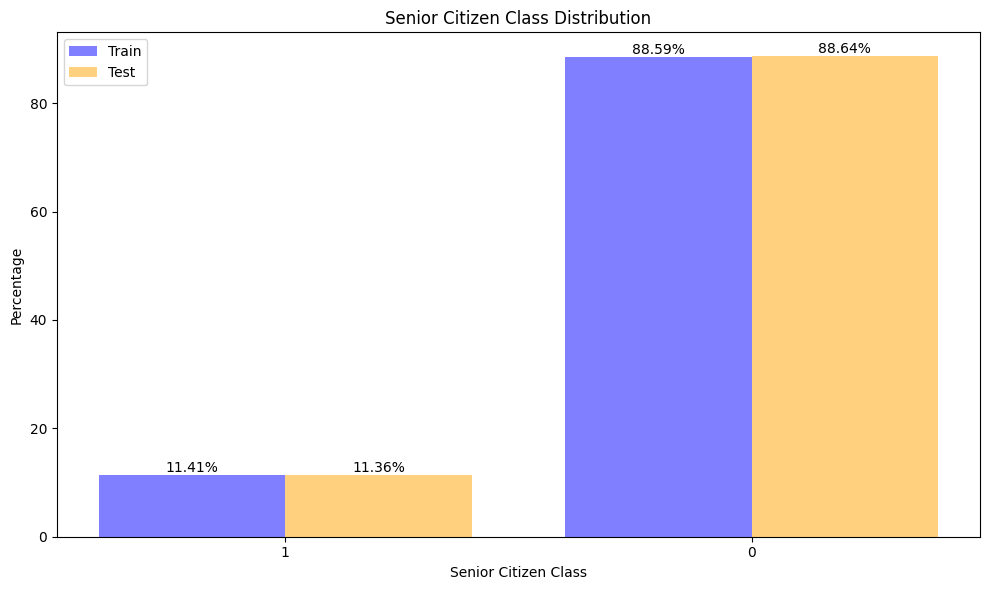

In [14]:
# Plot Chart
plot_bar_percentages(
    series_list = [train_df['SENIOR_CITIZEN'], test_df['SENIOR_CITIZEN']],
    labels = ['Train', 'Test'],
    x_label = 'Senior Citizen Class', 
    y_label = 'Percentage',
    title = 'Senior Citizen Class Distribution',
    colors = ('blue', 'orange'), 
    alpha = 0.5,
    fig_size = (10, 6)
)

In [15]:
# Tenure
print(f"Number of different values for Tenure (Training dataset): {train_df['TENURE'].nunique()}")
print(f"Number of different values for Tenure (Test dataset): {test_df['TENURE'].nunique()}")

Number of different values for Tenure (Training dataset): 72
Number of different values for Tenure (Test dataset): 72


In [16]:
train_tenure = set(train_df['TENURE'].tolist())
test_tenure = set(test_df['TENURE'].tolist())

common = sorted(train_tenure.intersection(test_tenure))
only_in_train = sorted(train_tenure - test_tenure)
only_in_test = sorted(test_tenure - train_tenure)

print(f"Values present in both datasets:\n{common}\n")
print(f"Values present only in train: {only_in_train}")
print(f"Values present only in test: {only_in_test}")

Values present in both datasets:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72]

Values present only in train: []
Values present only in test: []


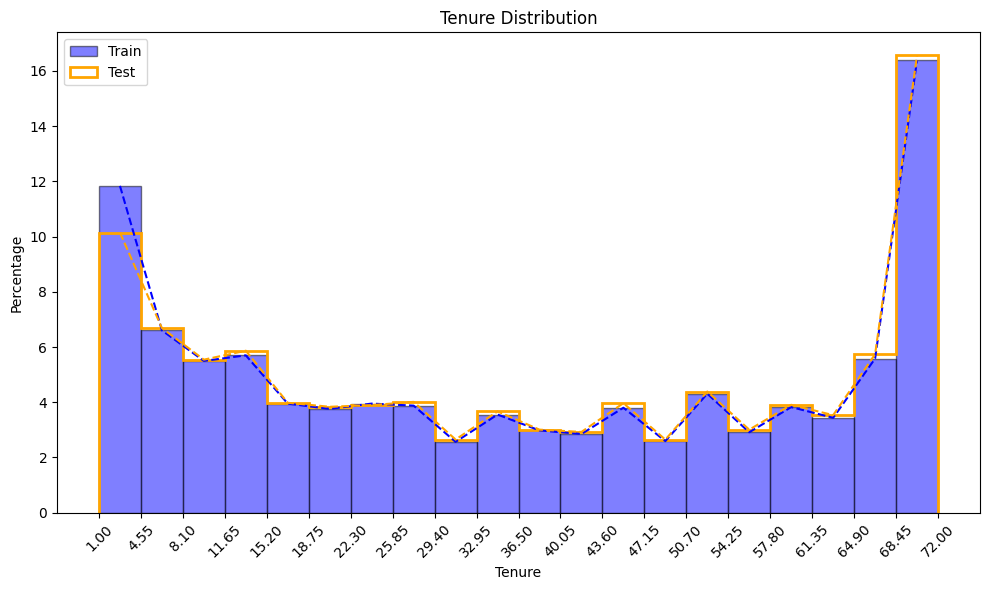

In [17]:
plot_hist_percentages(
    series1 = train_df['TENURE'], 
    series2 = test_df['TENURE'],
    num_bins = 20,
    label1 = 'Train', 
    label2 = 'Test', 
    x_label = 'Tenure', 
    y_label = 'Percentage',
    title = 'Tenure Distribution',
    colors = ('blue', 'orange'), 
    alpha = 0.5,
    fig_size = (10, 6)
)

In [18]:
# Monthly charges
print(f"Number of different values for Monthly Charges (Training dataset): {train_df['MONTHLY_CHARGES'].nunique()}")
print(f"Number of different values for Monthly Charges (Test dataset): {test_df['MONTHLY_CHARGES'].nunique()}")

Number of different values for Monthly Charges (Training dataset): 1921
Number of different values for Monthly Charges (Test dataset): 1875


In [19]:
train_monthly_charges = set(train_df['MONTHLY_CHARGES'].tolist())
test_monthly_charges = set(test_df['MONTHLY_CHARGES'].tolist())

common = sorted(train_monthly_charges.intersection(test_monthly_charges))
only_in_train = sorted(train_monthly_charges - test_monthly_charges)
only_in_test = sorted(test_monthly_charges - train_monthly_charges)

print(f"Values present only in train: {only_in_train}")
print(f"Values present only in test: {only_in_test}")
print("\n")
print(f"Number of values present in both datasets: {len(common)}")
print(f"Number of values present only in train: {len(only_in_train)}")
print(f"Number of values present only in test: {len(only_in_test)}")

Values present only in train: [18.25, 21.5, 21.7, 21.8, 22.45, 22.95, 24.86, 26.85, 26.9, 27.35, 27.4, 27.55, 28.1, 28.15, 28.2, 28.25, 28.35, 28.7, 28.85, 28.95, 30.95, 31.6, 31.65, 31.7, 31.75, 31.8, 31.85, 31.9, 32.45, 36.6, 36.7, 37.15, 37.25, 37.4, 37.45, 37.5, 37.65, 37.75, 37.95, 38.3, 41.5, 41.8, 41.95, 42.25, 42.85, 43.1, 46.65, 46.7, 46.9, 47.2, 48.1, 49.79, 52.95, 57.35, 60.11, 64.83, 67.3, 89.24, 93.86, 94.86, 94.96, 115.332, 117.3, 117.9]
Values present only in test: [18.65, 21.55, 21.85, 22.4, 22.9, 28.05, 28.65, 28.9, 30.92, 31.5, 31.55, 32.15, 32.35, 42.5, 44.86, 45.79, 52.9, 112.7]


Number of values present in both datasets: 1857
Number of values present only in train: 64
Number of values present only in test: 18


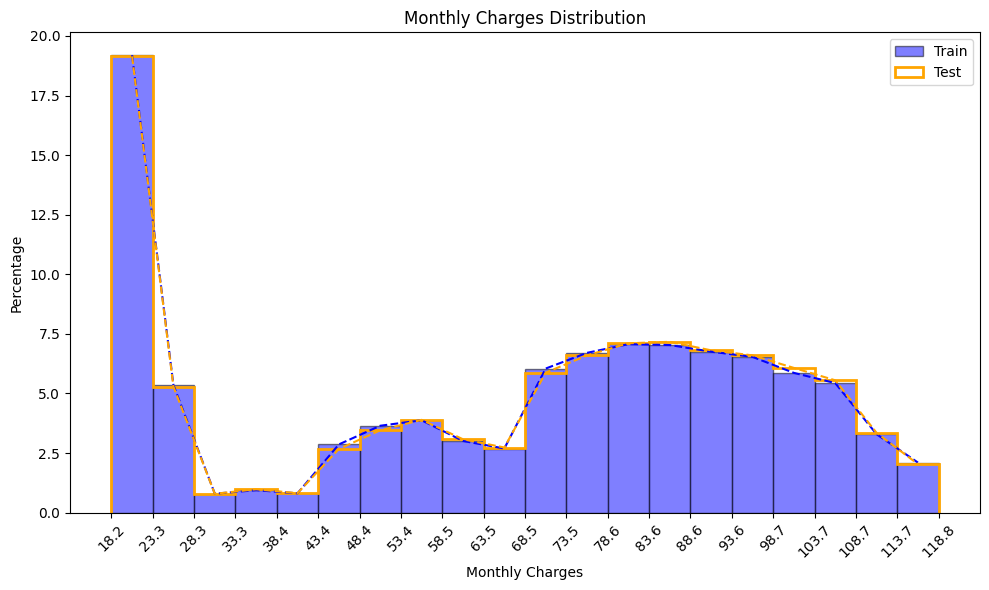

In [20]:
plot_hist_percentages(
    series1 = train_df['MONTHLY_CHARGES'], 
    series2 = test_df['MONTHLY_CHARGES'],
    num_bins = 20,
    label1 = 'Train', 
    label2 = 'Test', 
    x_label = 'Monthly Charges', 
    y_label = 'Percentage',
    title = 'Monthly Charges Distribution',
    colors = ('blue', 'orange'), 
    alpha = 0.5,
    fig_size = (10, 6)
)

In [21]:
# Total charges
print(f"Number of different values for Total Charges (Training dataset): {train_df['TOTAL_CHARGES'].nunique()}")
print(f"Number of different values for Total Charges (Test dataset): {test_df['TOTAL_CHARGES'].nunique()}")

Number of different values for Total Charges (Training dataset): 31910
Number of different values for Total Charges (Test dataset): 24995


In [22]:
train_total_charges = set(train_df['TOTAL_CHARGES'].tolist())
test_total_charges = set(test_df['TOTAL_CHARGES'].tolist())

common = sorted(train_total_charges.intersection(test_total_charges))
only_in_train = sorted(train_total_charges - test_total_charges)
only_in_test = sorted(test_total_charges - train_total_charges)

print(f"Number of values present in both datasets: {len(common)}")
print(f"Number of values present only in train: {len(only_in_train)}")
print(f"Number of values present only in test: {len(only_in_test)}")

Number of values present in both datasets: 21696
Number of values present only in train: 10214
Number of values present only in test: 3299


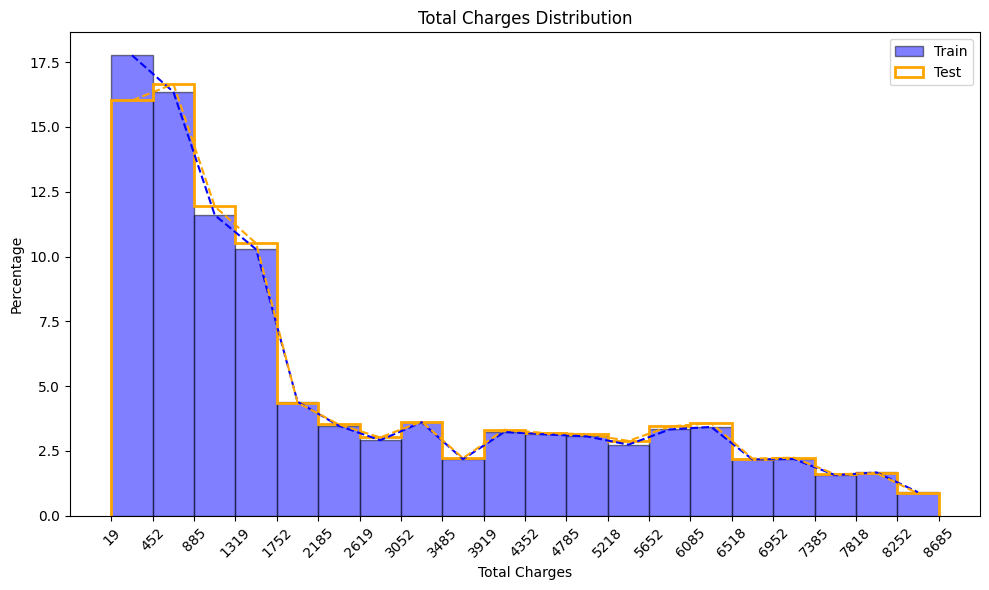

In [23]:
plot_hist_percentages(
    series1 = train_df['TOTAL_CHARGES'], 
    series2 = test_df['TOTAL_CHARGES'],
    num_bins = 20,
    label1 = 'Train', 
    label2 = 'Test', 
    x_label = 'Total Charges', 
    y_label = 'Percentage',
    title = 'Total Charges Distribution',
    colors = ('blue', 'orange'), 
    alpha = 0.5,
    fig_size = (10, 6)
)

**`Observations - NUMERICAL Columns`**
- Distribution Consistency
  - All features show consistent distributions between train and test datasets, indicating no significant distribution shift. The model trained on the training set should generalize well to the test set.
  - No outliers detected in any continuous feature across both datasets.
- Senior Citizen
  - `Heavily imbalanced`, approximately **89%** non-senior citizens vs **11%** senior citizens in both datasets.
  - Class imbalance may need to be addressed during modelling (e.g. `class_weight`, `scale_pos_weight`).
- Tenure
  - `No Unseel Values`: Ranges from 1 to 72 months with identical unique values in both train and test.
  - `Bimodal pattern`: High concentration at very low tenure (1-5 months) and very high tenure (68-72 months).
  - Could likely be one of the strongest predictors of churn, suggesting two distinct customer groups.
    - `New customers who churn early`
    - `Loyal long-term customers`
- Monthly Charges
  - `Bimodal distribution`: Spike at lower end (18-23) representing basic plan customers, broader peak in 68-108 range representing premium plan customers.
  - Noticeable gap between ~28 and ~43 suggesting distinct pricing tiers with no customers in between. Worth investigating correlation with churn.
- Total Charges
  - `Right-skewed distribution`: Most customers have relatively low total charges, with fewer long-tenure high-spending customers at the tail.
  - Largest feature mismatch between datasets: Train has 31,910 unique values vs Test has 24,995, with only 21,696 overlapping values.

### Categorical Columns

In [24]:
categorical_columns = train_df.select_dtypes(include = "object").columns
categorical_columns = np.delete(categorical_columns, 15)
categorical_columns = np.hstack((categorical_columns, ['SENIOR_CITIZEN']))
categorical_columns

array(['GENDER', 'PARTNER', 'DEPENDENTS', 'PHONE_SERVICE',
       'MULTIPLE_LINES', 'INTERNET_SERVICE', 'ONLINE_SECURITY',
       'ONLINE_BACKUP', 'DEVICE_PROTECTION', 'TECH_SUPPORT',
       'STREAMING_TV', 'STREAMING_MOVIES', 'CONTRACT',
       'PAPERLESS_BILLING', 'PAYMENT_METHOD', 'SENIOR_CITIZEN'],
      dtype=object)

In [25]:
# Gender
train_df['GENDER'].value_counts()

GENDER
Female    298738
Male      295456
Name: count, dtype: int64

In [26]:
# Partner
train_df['PARTNER'].value_counts()

PARTNER
Yes    309554
No     284640
Name: count, dtype: int64

In [27]:
# Dependents
train_df['DEPENDENTS'].value_counts()

DEPENDENTS
No     414362
Yes    179832
Name: count, dtype: int64

In [28]:
# Phone Service
train_df['PHONE_SERVICE'].value_counts()

PHONE_SERVICE
Yes    557893
No      36301
Name: count, dtype: int64

In [29]:
# Muliple Lines
train_df['MULTIPLE_LINES'].value_counts()

MULTIPLE_LINES
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64

In [30]:
# Internet Service
train_df['INTERNET_SERVICE'].value_counts()

INTERNET_SERVICE
Fiber optic    272386
DSL            181081
No             140727
Name: count, dtype: int64

In [31]:
# Online Security
train_df['ONLINE_SECURITY'].value_counts()

ONLINE_SECURITY
No                     289474
Yes                    163993
No internet service    140727
Name: count, dtype: int64

In [32]:
# Online Backup
train_df['ONLINE_BACKUP'].value_counts()

ONLINE_BACKUP
No                     250083
Yes                    203384
No internet service    140727
Name: count, dtype: int64

In [33]:
# Device Protection
train_df['DEVICE_PROTECTION'].value_counts()

DEVICE_PROTECTION
No                     247377
Yes                    206090
No internet service    140727
Name: count, dtype: int64

In [34]:
# Tech Support
train_df['TECH_SUPPORT'].value_counts()

TECH_SUPPORT
No                     288571
Yes                    164896
No internet service    140727
Name: count, dtype: int64

In [35]:
# Streaming TV
train_df['STREAMING_TV'].value_counts()

STREAMING_TV
Yes                    240301
No                     213166
No internet service    140727
Name: count, dtype: int64

In [36]:
# Streaming Movies
train_df['STREAMING_MOVIES'].value_counts()

STREAMING_MOVIES
Yes                    241435
No                     212032
No internet service    140727
Name: count, dtype: int64

In [37]:
# Contract
train_df['CONTRACT'].value_counts()

CONTRACT
Month-to-month    298918
Two year          186943
One year          108333
Name: count, dtype: int64

In [38]:
# Paperless Billing
train_df['PAPERLESS_BILLING'].value_counts()

PAPERLESS_BILLING
Yes    365579
No     228615
Name: count, dtype: int64

In [39]:
# Payment Method
train_df['PAYMENT_METHOD'].value_counts()

PAYMENT_METHOD
Electronic check             215372
Credit card (automatic)      133705
Mailed check                 123757
Bank transfer (automatic)    121360
Name: count, dtype: int64

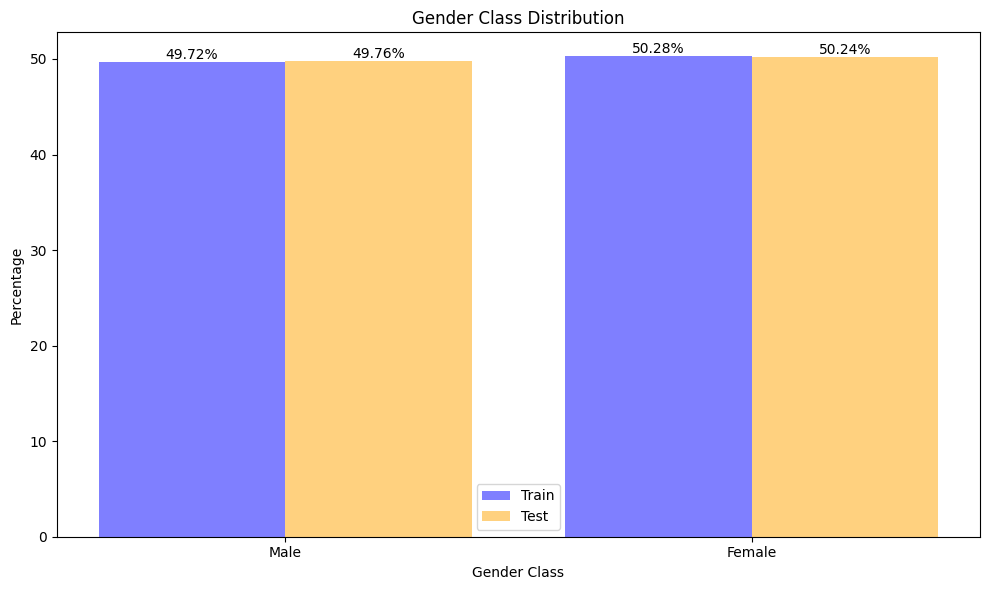

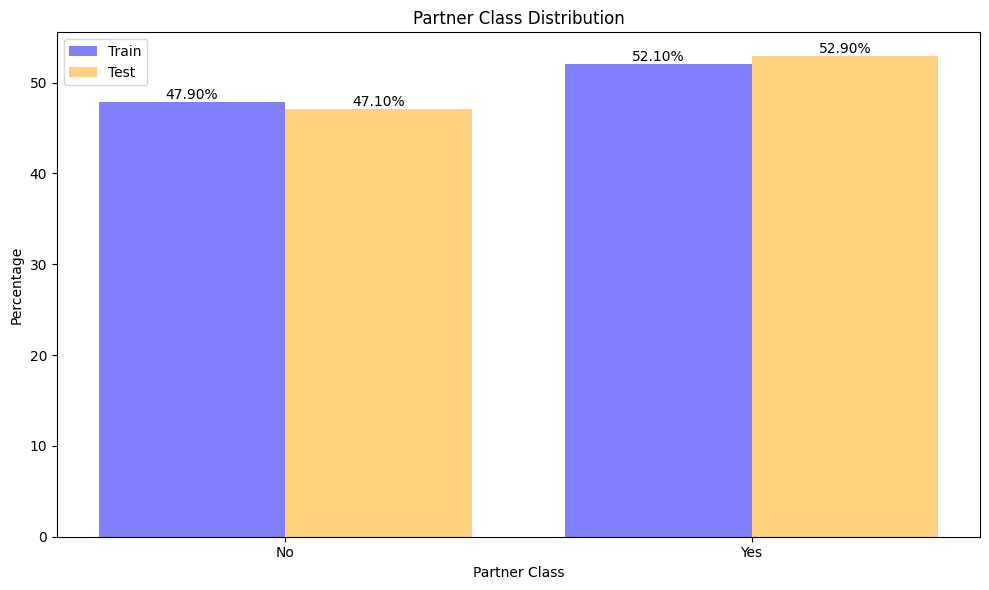

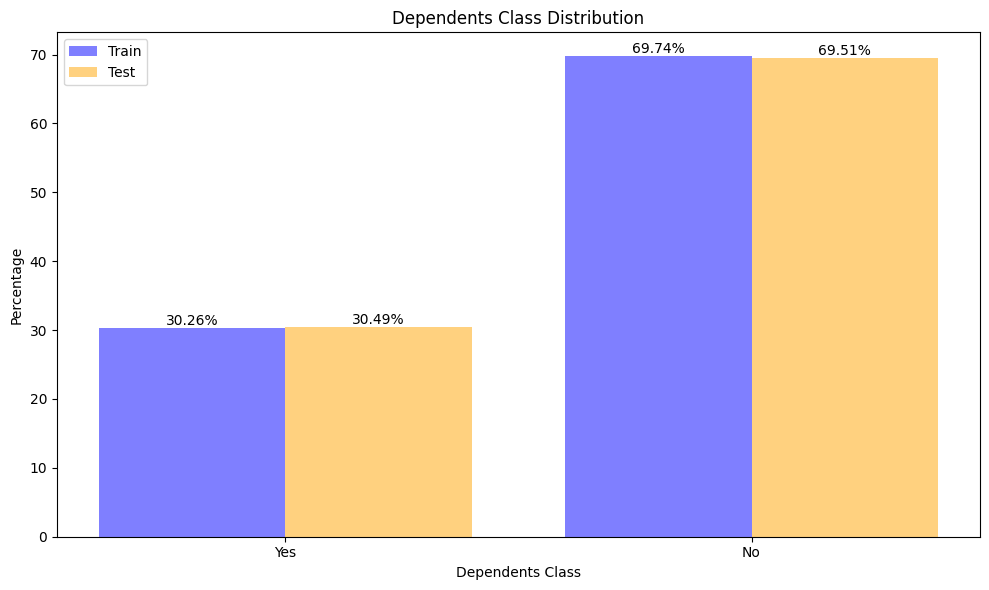

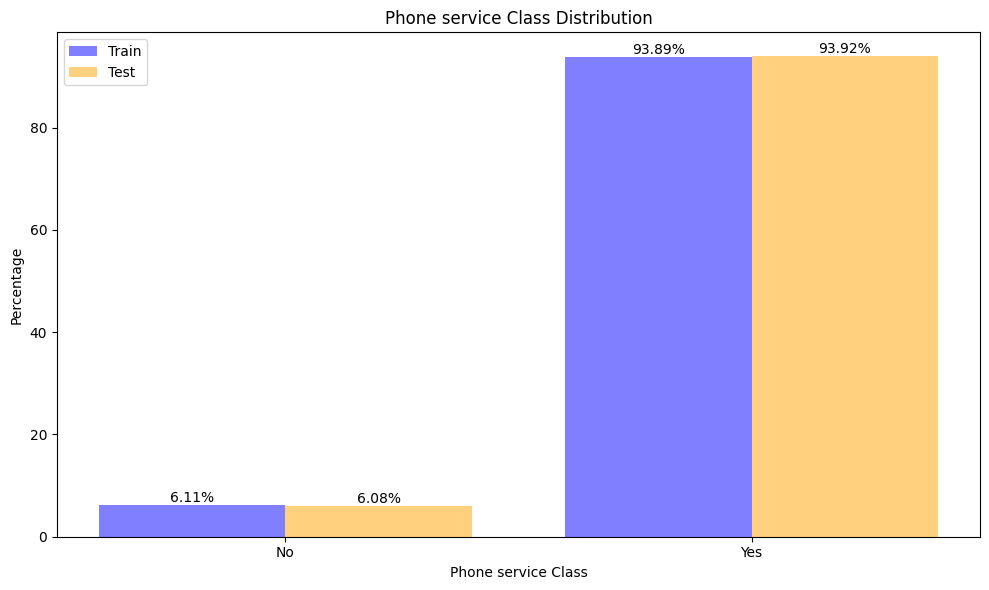

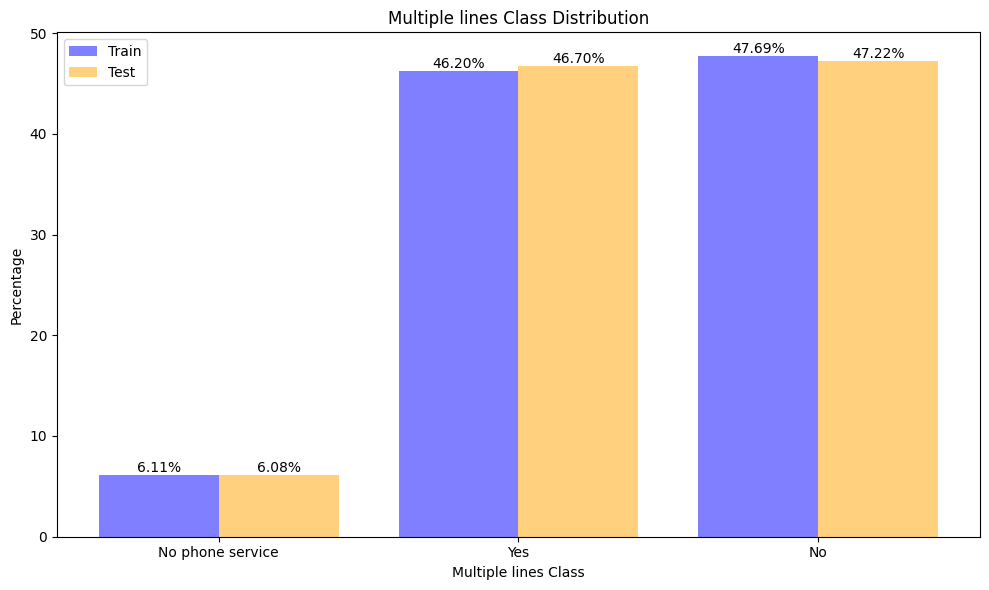

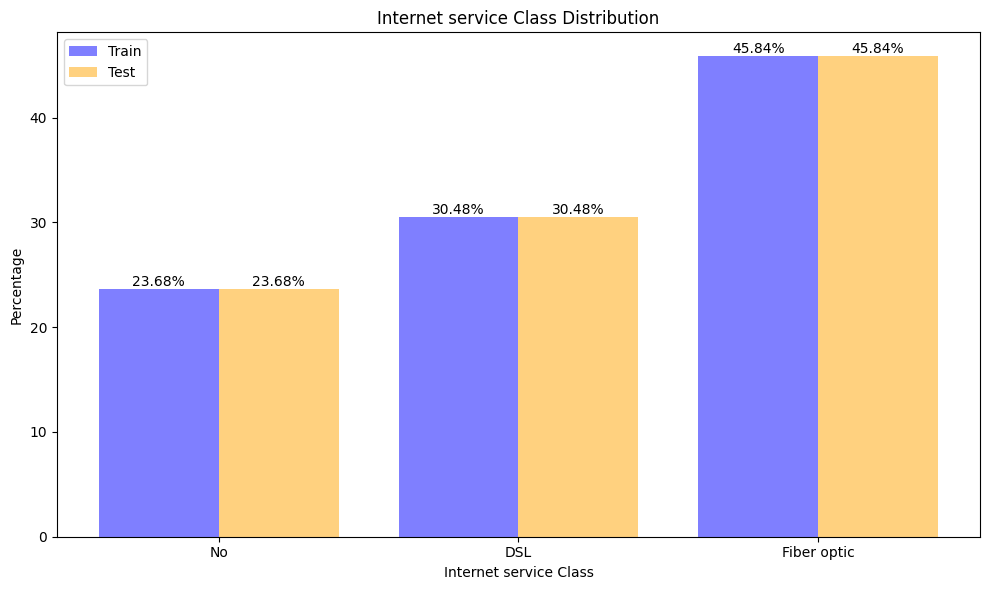

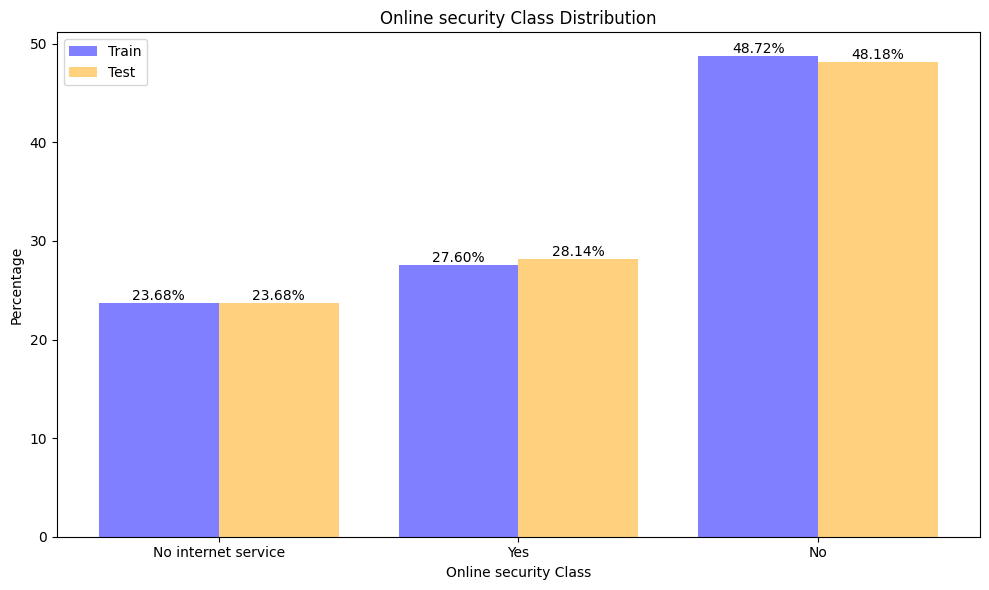

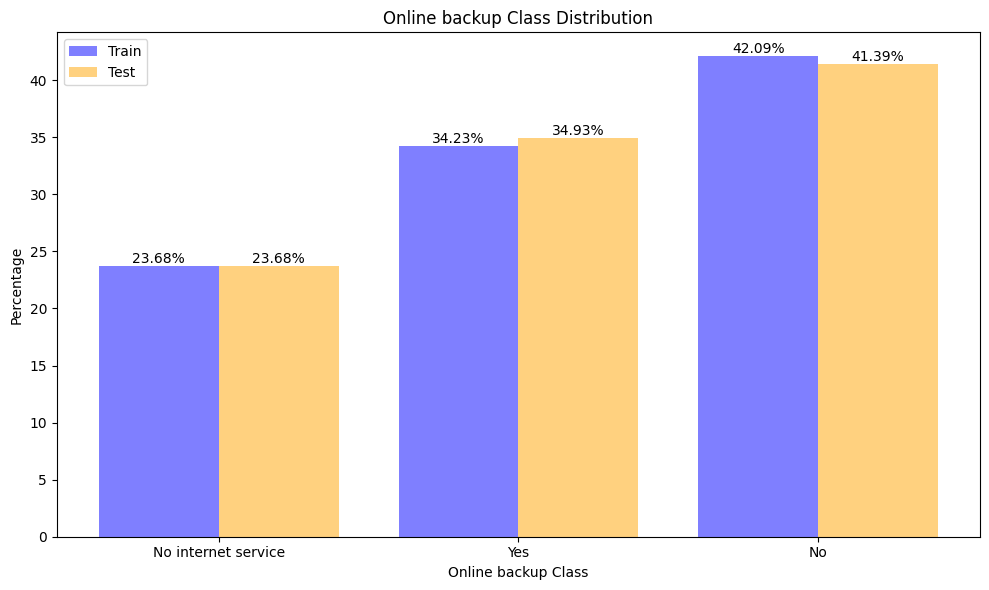

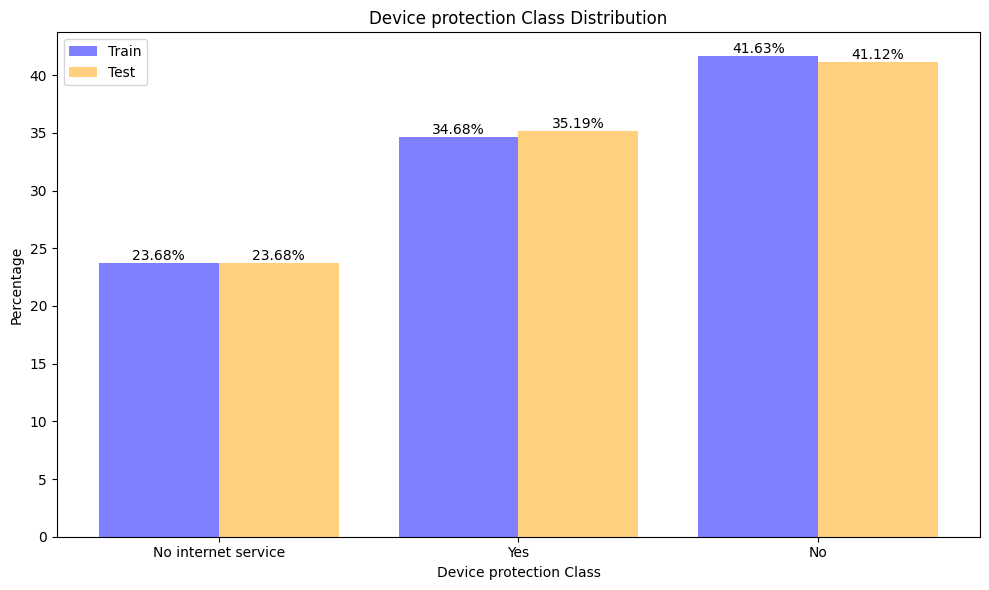

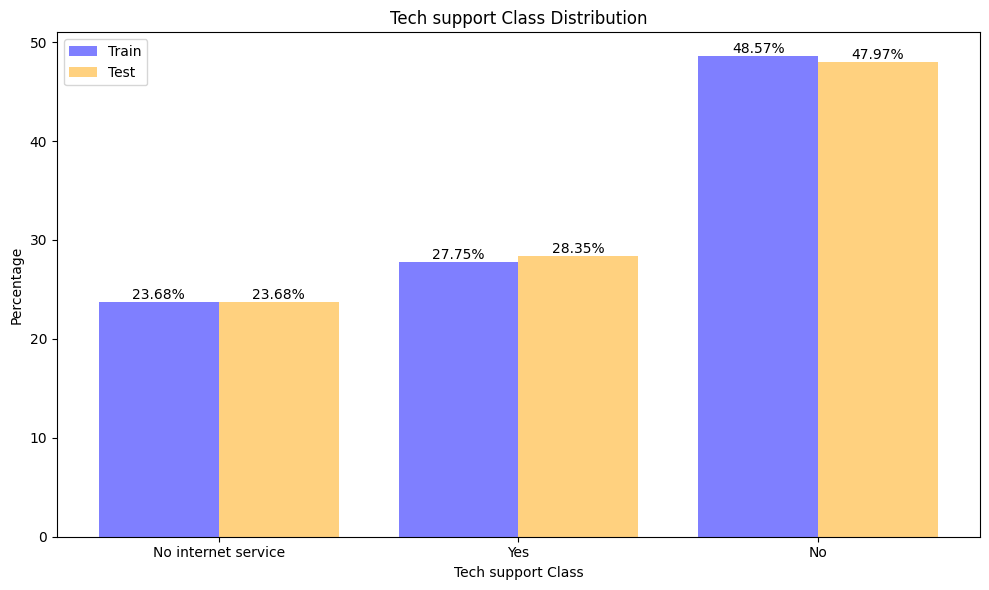

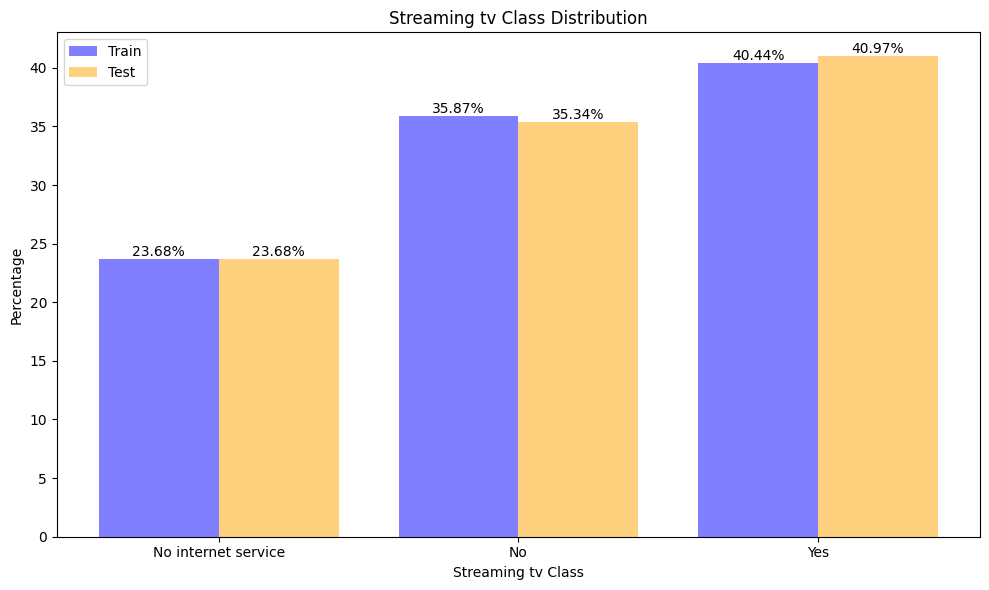

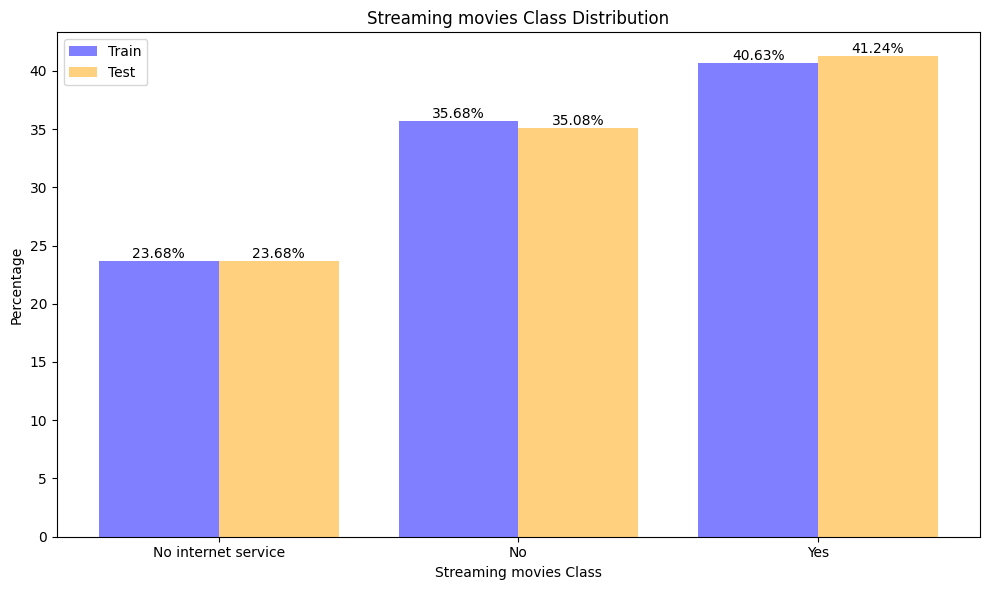

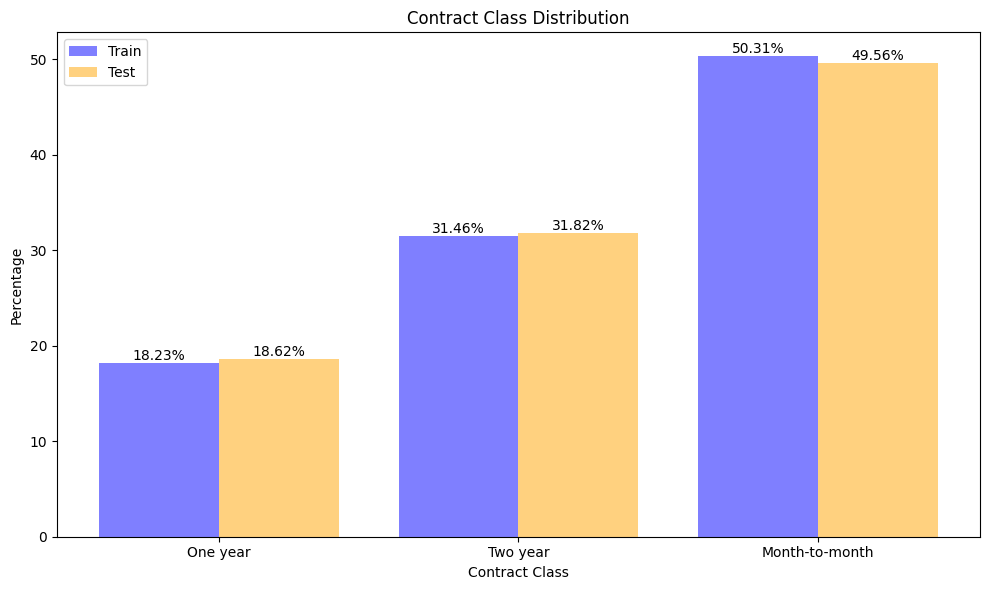

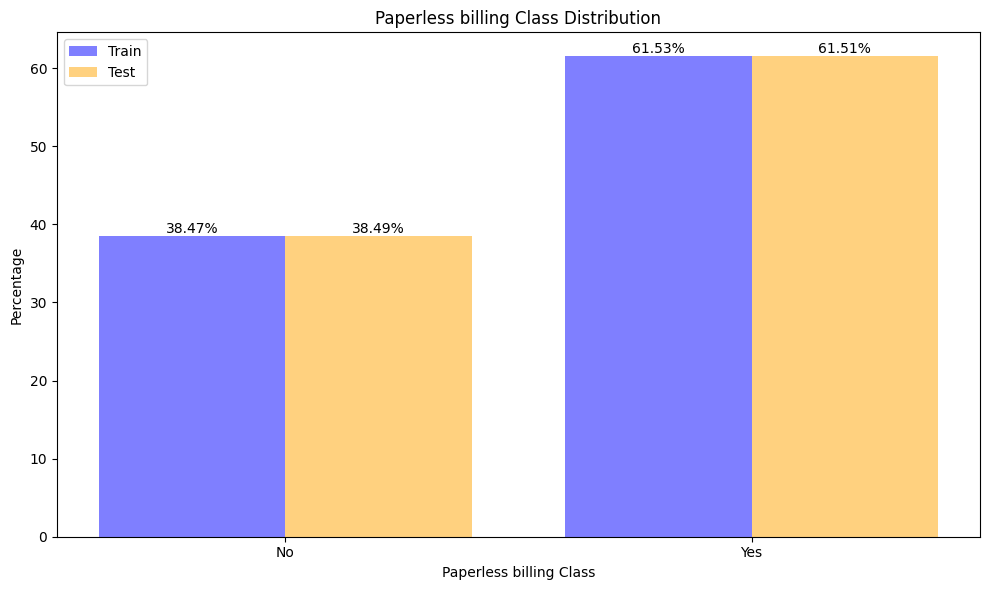

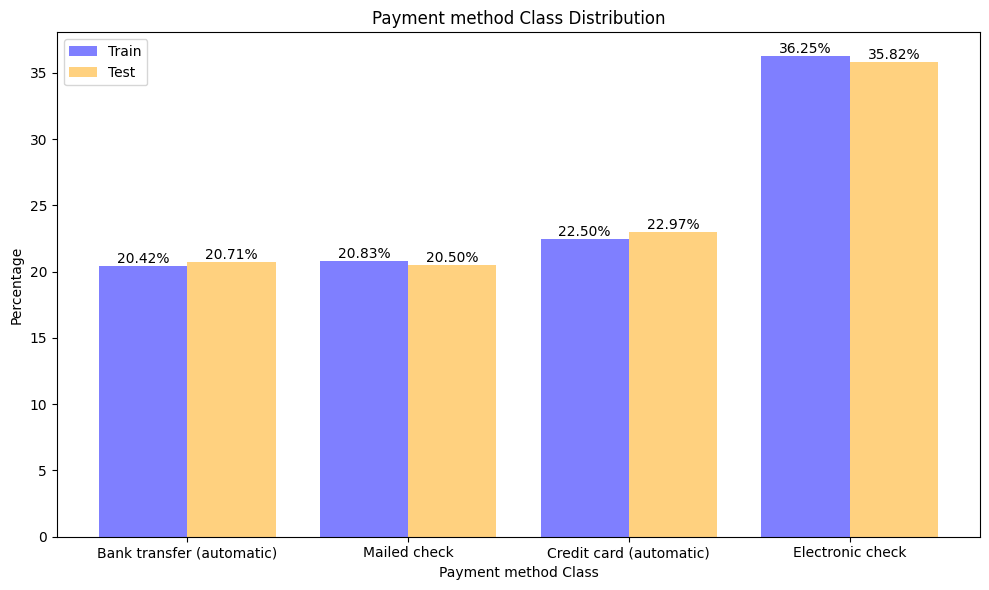

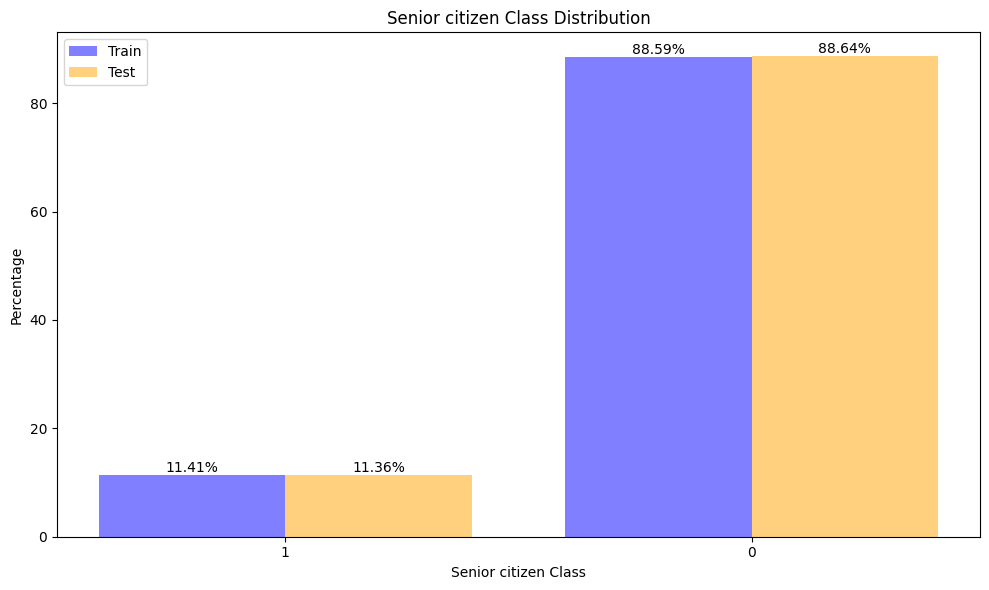

In [40]:
for col in categorical_columns:
    # Plot Chart
    plot_bar_percentages(
        series_list = [train_df[col], test_df[col]],
        labels = ['Train', 'Test'],
        x_label = f"{col.replace('_', ' ').capitalize()} Class", 
        y_label = 'Percentage',
        title = f"{col.replace('_', ' ').capitalize()} Class Distribution",
        colors = ['blue', 'orange'], 
        alpha = 0.5,
        fig_size = (10, 6)
    )

**`Observations - CATEGORICAL Columns`**
- Distribution Consistency
  - Train and test datasets follow nearly `identical distributions` across all categorical variables, indicating that the dataset split is well balanced and unlikely to introduce sampling bias during model training or evaluation.
- Low Variance Features
  - `Gender` has nearly perfectly balanced (~50/50) two classes. Very low variance, likely a weak predictor of churn.
  - `Phone Service` ~94% of customers have phone service. Almost no variance, **can be dropped**.
- Class Imbalance
  - `Senior Citizen` is heavily imbalanced (**~89%** non-senior vs **~11%** senior). May need to be addressed during modelling.
  - `Dependents` ~70% of customers have no dependents. Moderate imbalance.
- Potential Multicollinearity
  - `Streaming TV` and `Streaming Movies` show near-identical distributions. `Likely strongly correlated`.
  - `Online Backup` and `Device Protection` show very similar distributions. `Likely correlated`.
  - `Online Security` and `Tech Support` also show similar patterns. 
- Internet Service Linked Features
  - `Online Security`, `Online Backup`, `Device Protection`, `Tech Support`, `Streaming TV`, `Streaming Movies`
    - All share an identical **"No Internet Service"** category at exactly **23.68%** in both train and test.
    - This is directly tied to the ~23.68% of customers with no internet service in the Internet Service feature.
    - These features are therefore structurally dependent on Internet Service.
- Strong Potential Predictors
  - `Contract Type`: ~50% month-to-month, ~31% two-year, ~18% one-year. Month-to-month customers are historically the most likely to churn. Likely one of the strongest predictors.
  - `Payment Method`: Electronic check dominates at ~36%, while the other three methods are evenly distributed at ~20-23% each. Electronic check customers may exhibit higher churn, worth investigating.
  - `Paperless Billing`: ~62% Customers are opted in paperless billing. Tech-savvy customers may behave differently in terms of churn.
  - `Dependents and Partner`: Customers without dependents or partners may have less commitment to staying, potentially higher churn risk.
- Feature Engineering Suggestions
  - `HAS_INTERNET_SERVICE`: Binary flag from Internet Service. 
  - `NUM_ADDONS`: Count of opted add-on services (`Online Security`, `Online Backup`, `Device Protection`, `Tech Support`, `Streaming TV`, `Streaming Movies`)
  - `IS_AUTO_PAYMENT`: Binary flag grouping Bank Transfer and Credit Card (automatic) vs manual payment methods

## Target Class

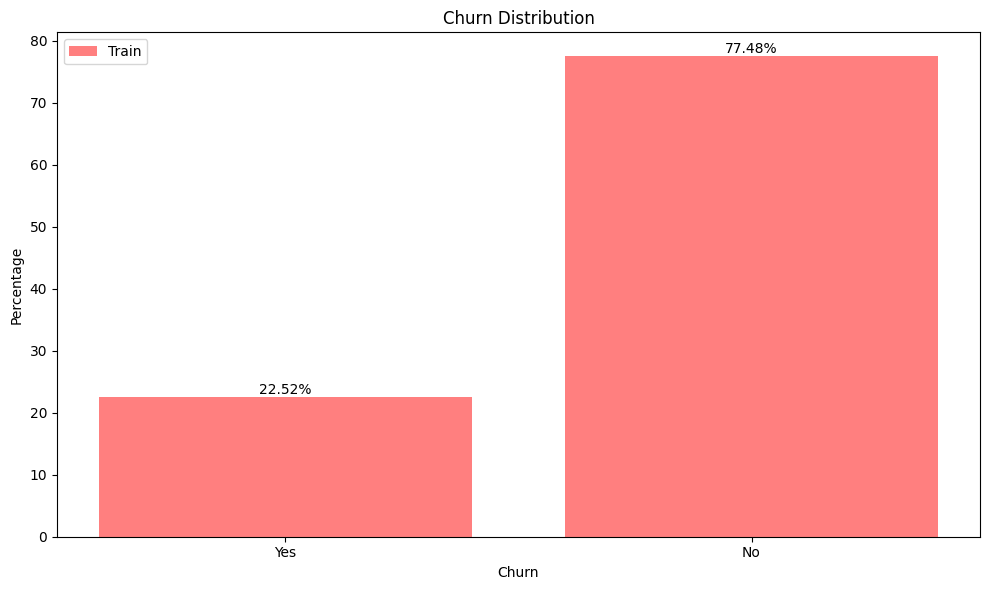

In [41]:
plot_bar_percentages(
    series_list = [train_df['CHURN']],
    labels = ['Train'],
    x_label = 'Churn',
    y_label = 'Percentage',
    title = 'Churn Distribution',
    colors = ['red'],
    alpha = 0.5,
    fig_size = (10, 6)
)

**`Observations - TARGET Class`**
- Class Imbalance
  - The target variable is imbalanced, **22.52% churn (Yes)** vs **77.48% no churn (No)**.
  - I'll be using `scale_pos_weight = 3.44` (77.48 / 22.52) for XGBoost to account for this.
- Metrics
  - **Accuracy** as a metrics is useless. Since, predicting "No" for every sample, would still give **~77.5% accuracy**.
  - **ROC-AUC** would be the primary metric for this problem. It tells us how well the model separates churners from non-churners across all thresholds.
  - **Precision**: Out of all customers the model flagged as churners, how many actually were?
  - **Recall**: Out of all customers who actually churned, how many did we catch?
  - **F1 Score**: A balance between Precision and Recall.
  - In a real business setting, I'd prioritize **Recall over Precision**. Since, missing a churner is more costly than sending a retention offer to someone who wasn't going to leave anyway.

## Exploratory Data Analytics

### Bivariate Analysis - CATEGORICAL Columns

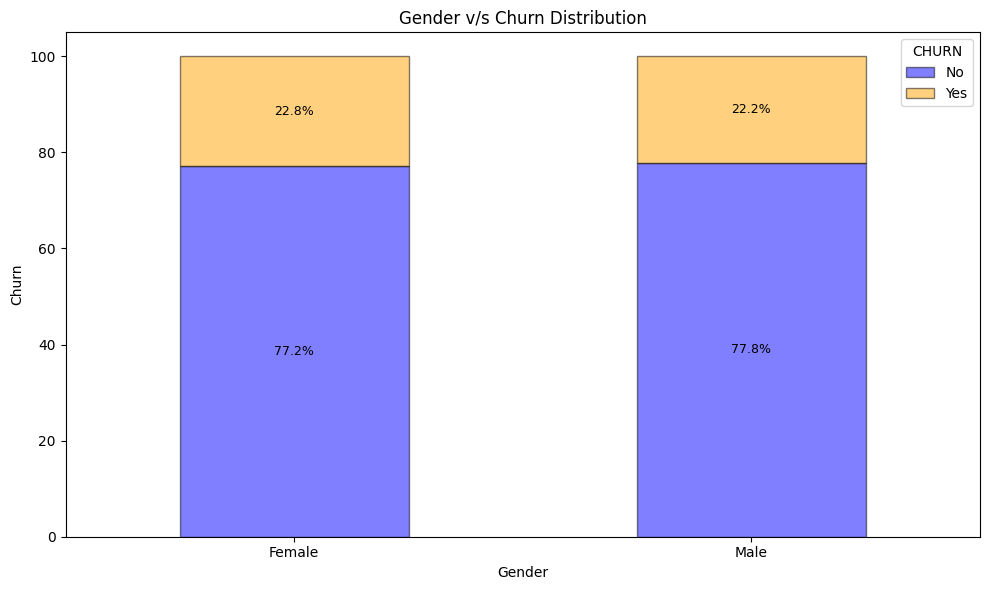

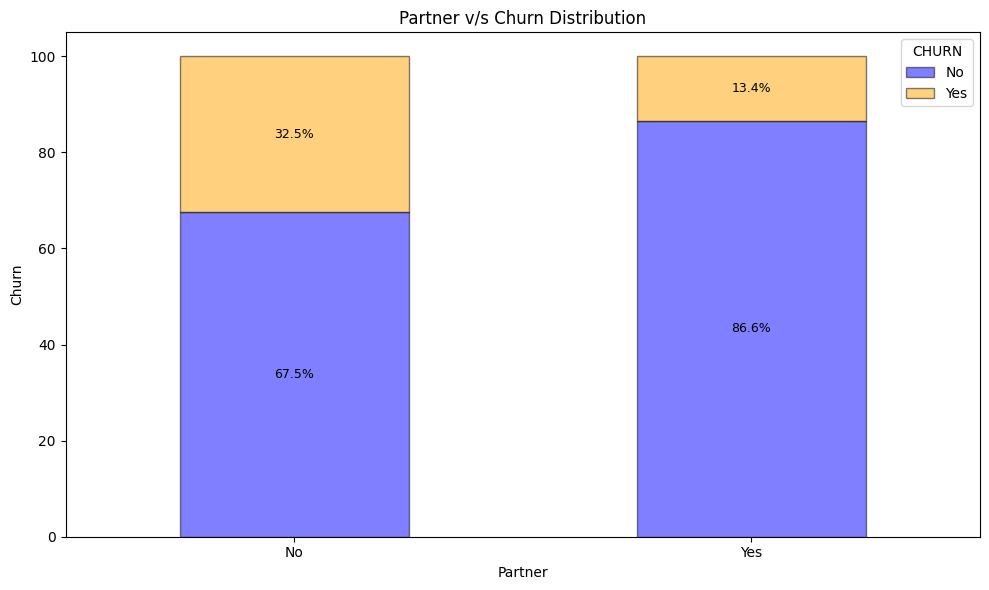

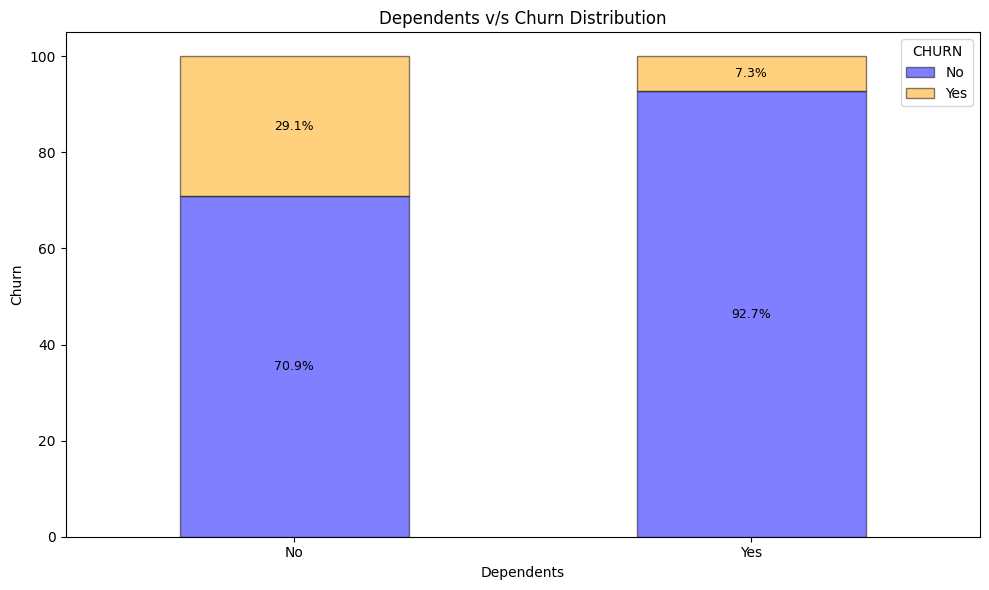

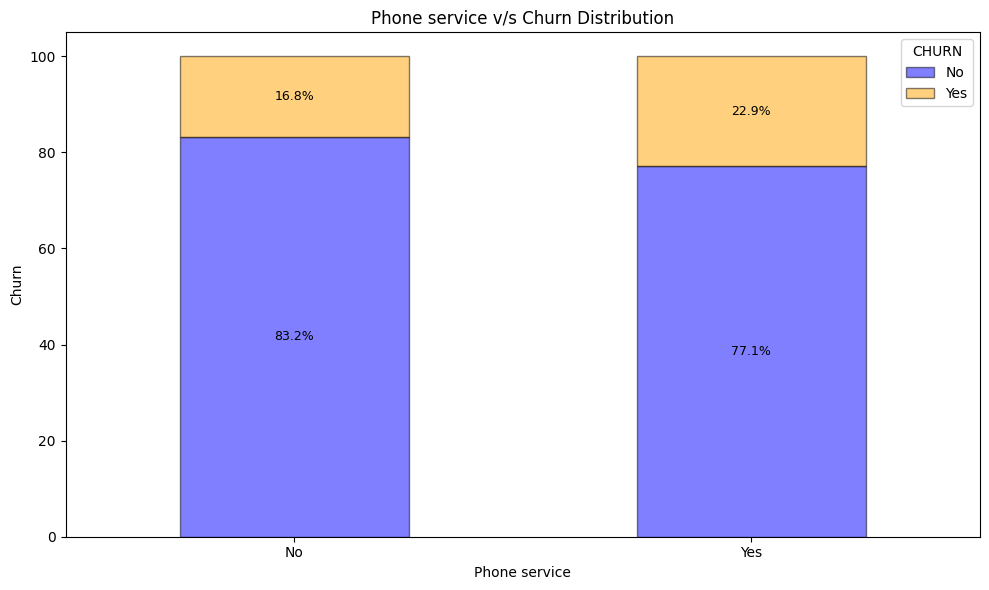

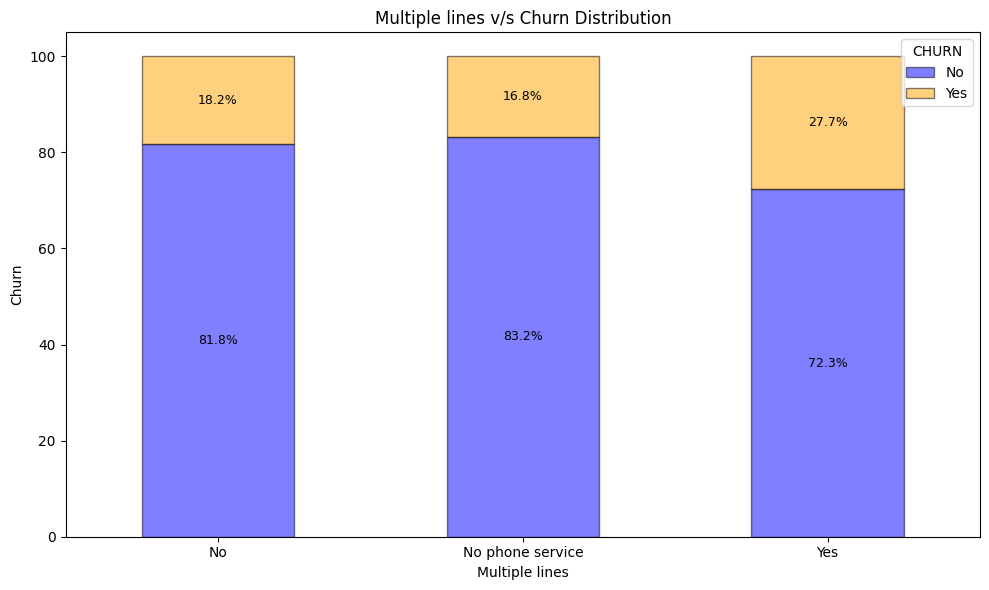

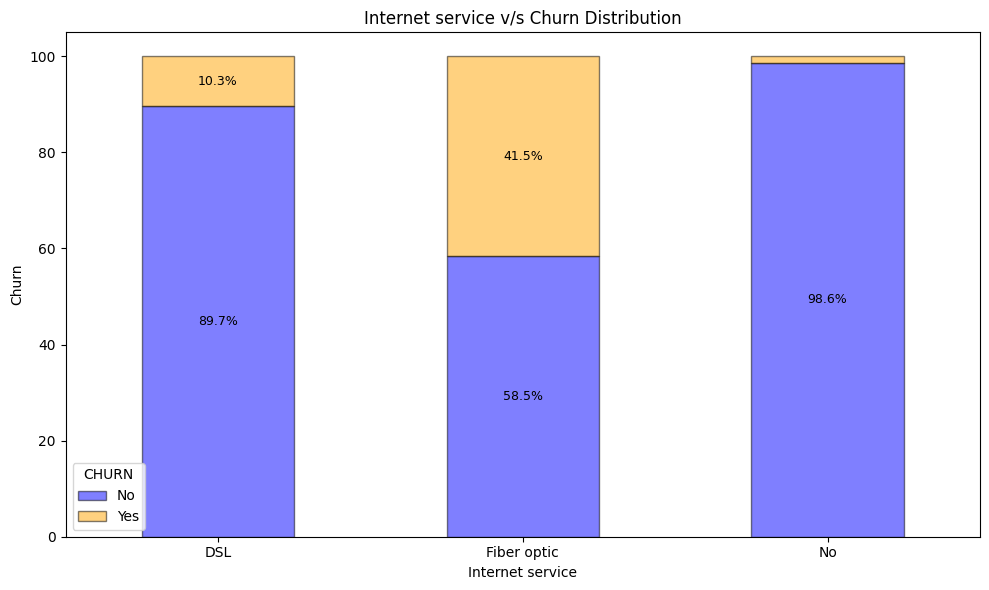

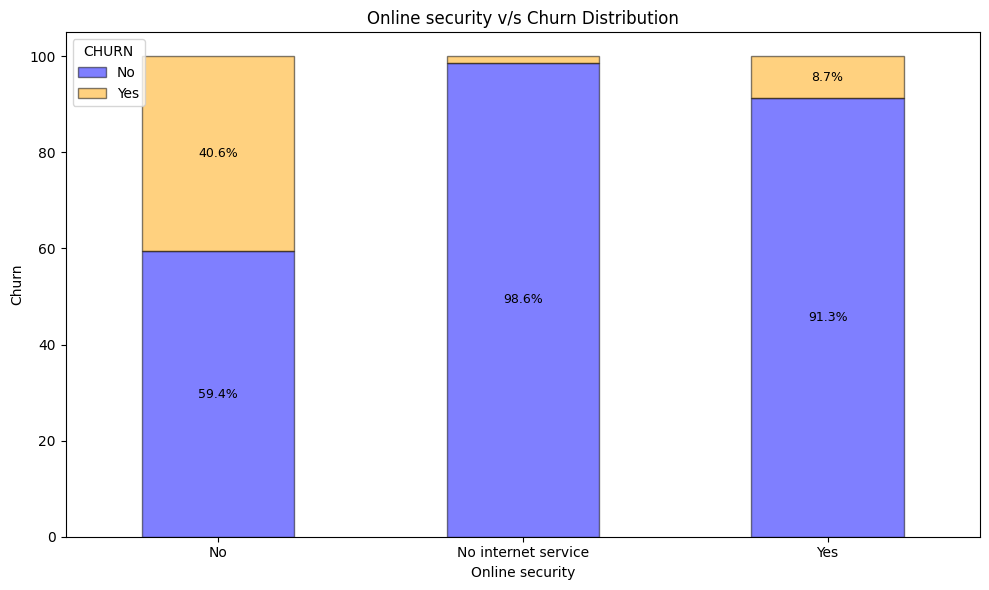

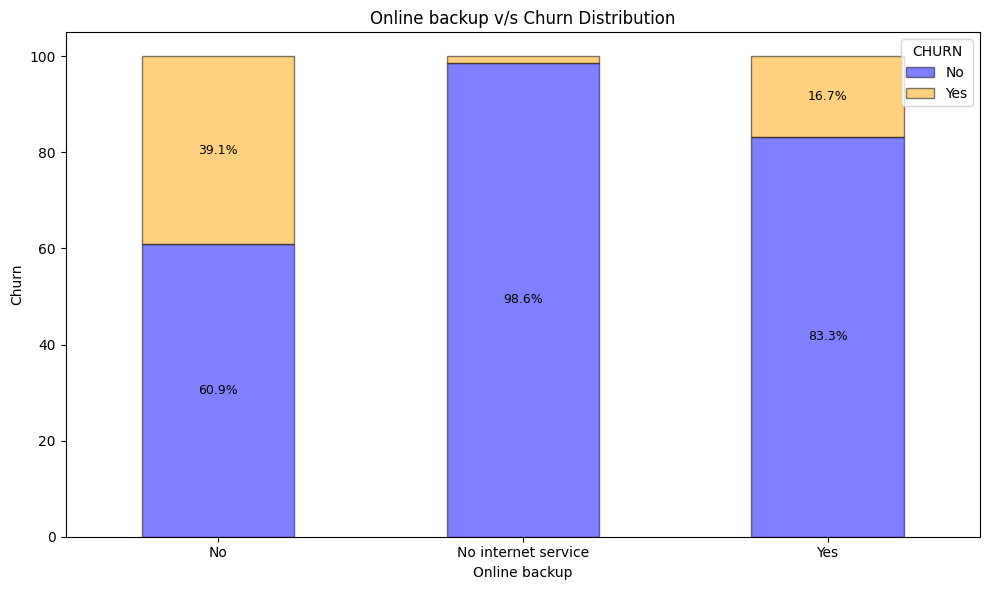

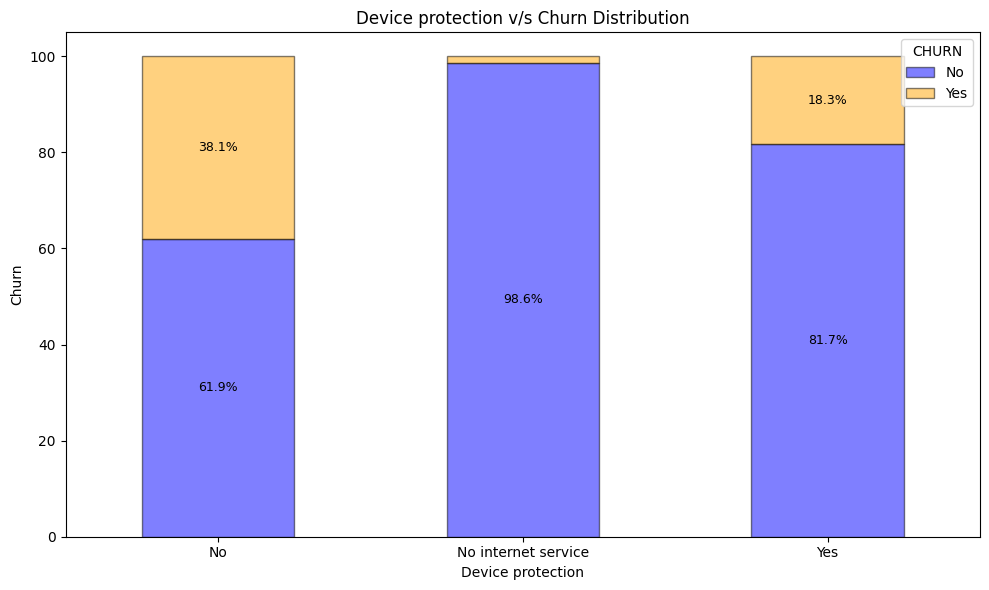

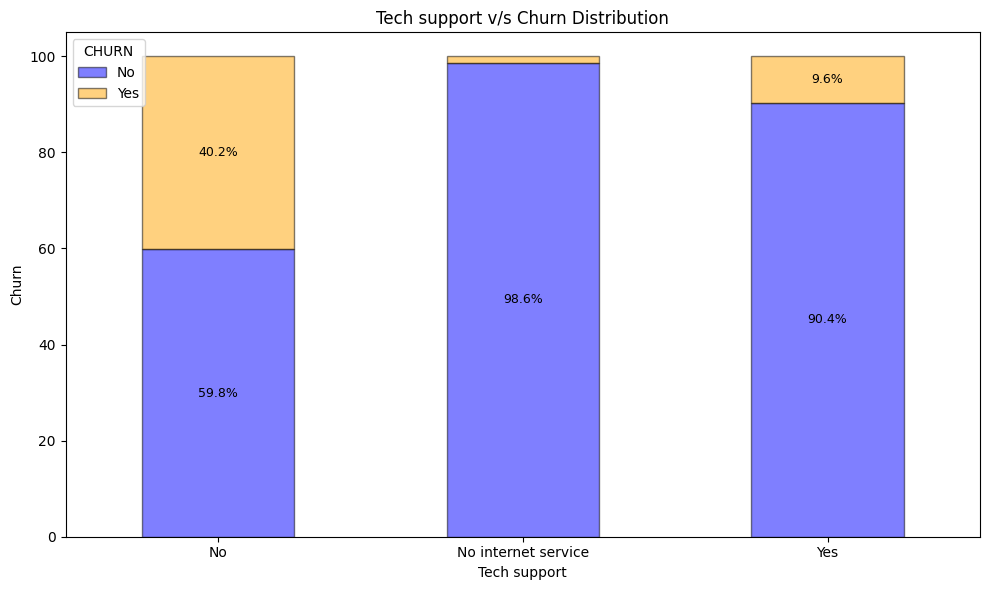

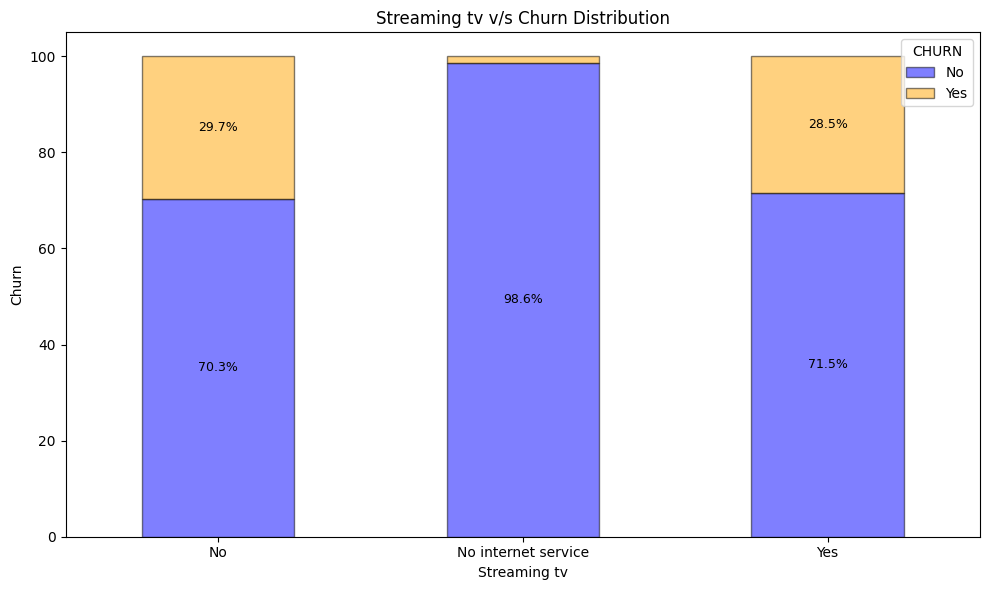

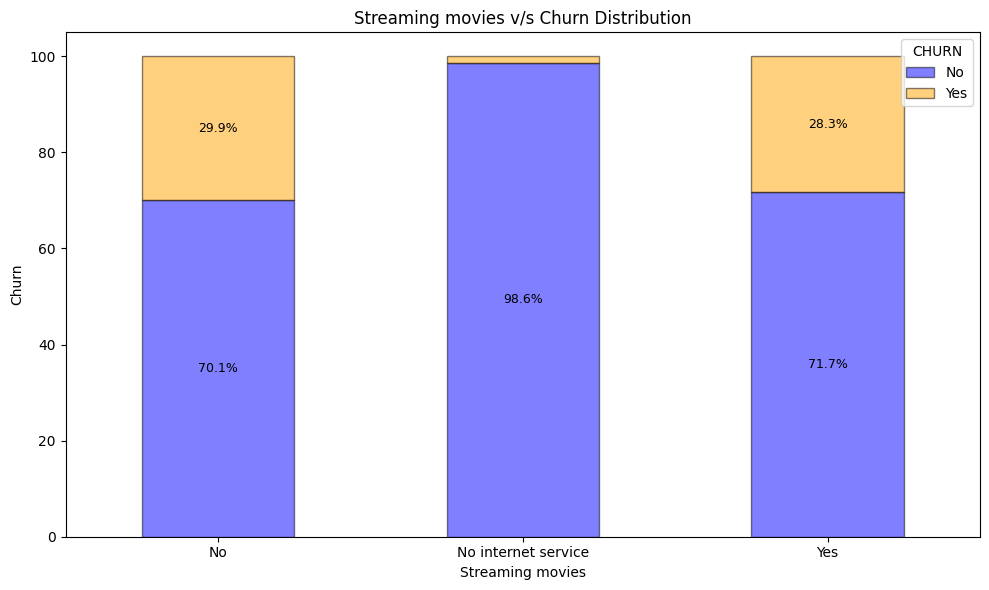

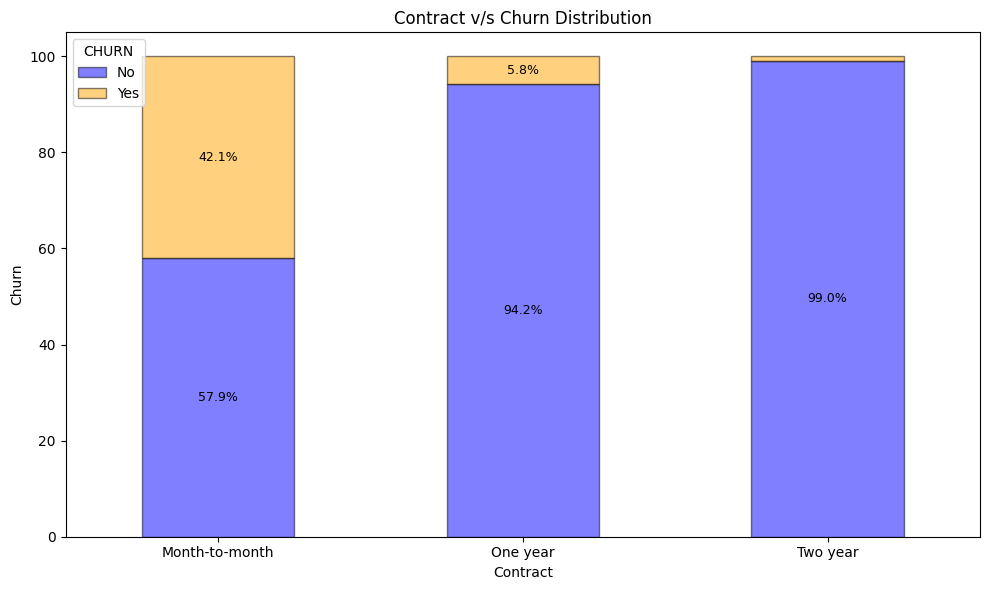

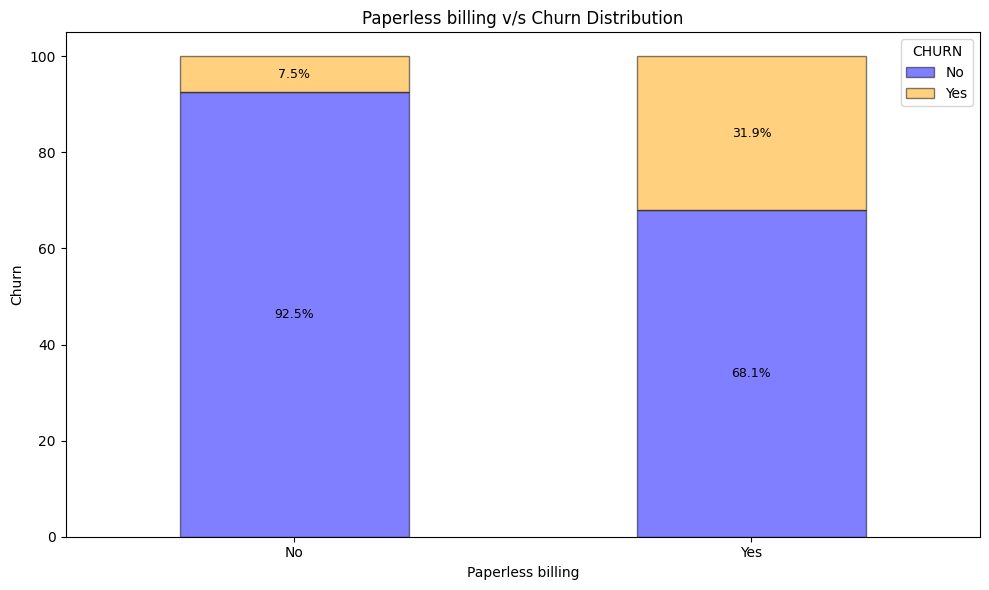

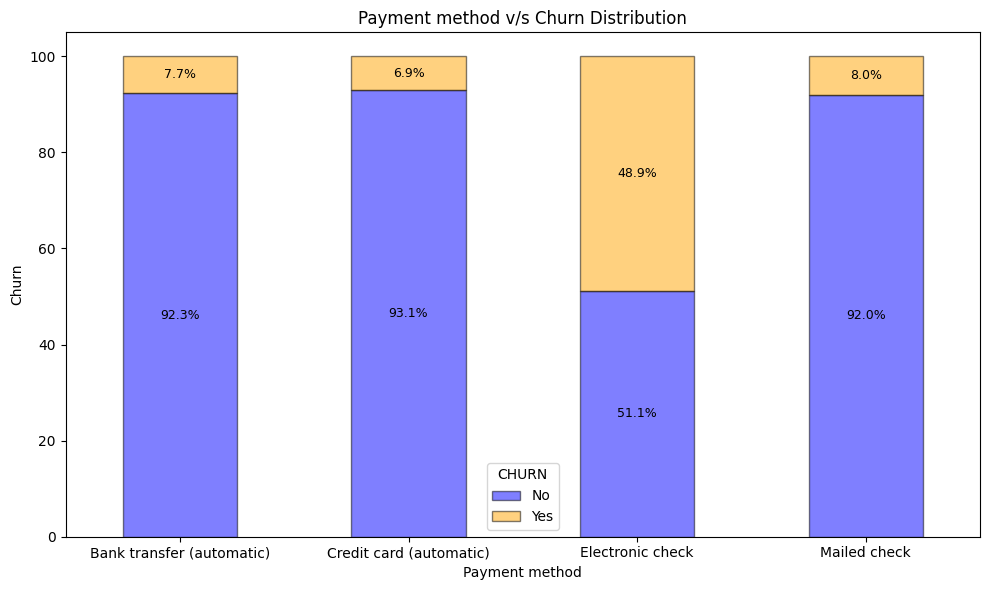

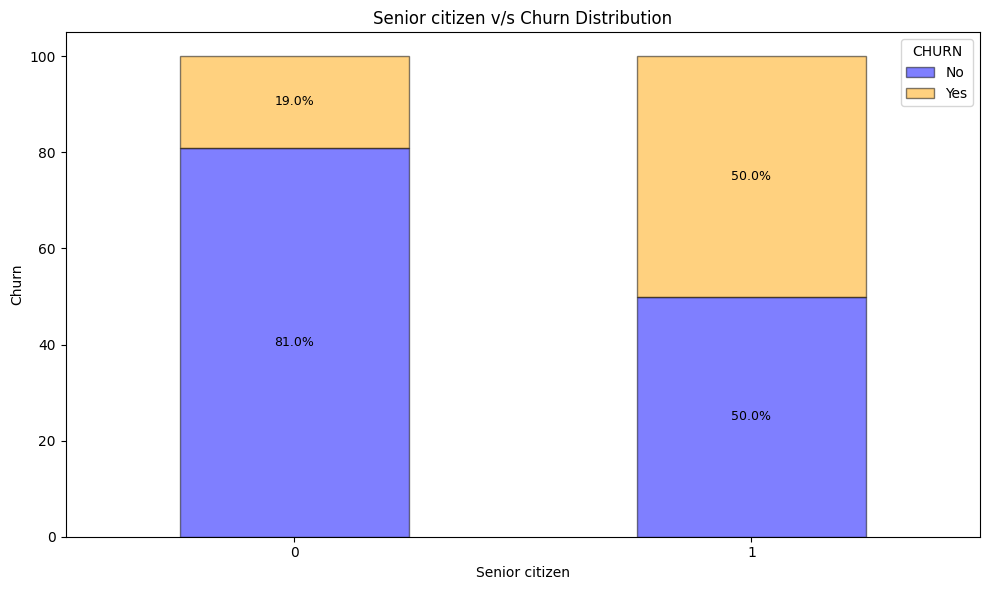

In [42]:
for col in categorical_columns:
    plot_stacked_bar_by_target(
        feature = train_df[col],
        target = train_df['CHURN'], 
        x_label = f"{col.replace('_', ' ').capitalize()}",
        y_label = 'Churn',
        title = f"{col.replace('_', ' ').capitalize()} v/s Churn Distribution",
        colors = ['blue', 'orange'],
        alpha = 0.5,
        rotation = 0,
        fig_size = (10, 6)
    )

**`Observations - Bivariate Analysis for Categorical Columns`**
- `SENIOR_CITIZEN`
  - Senior citizens exhibit a significantly higher churn rate, with approximately **50%** of senior customers leaving, compared to only **19%** churn among non-senior customers.
- `GENDER` shows almost identical churn rates (22.8% female vs 22.2% male).
  - **We can drop the feature.**
- `PARTNER` shows a significant difference.
  - Customers **without a partner churn at 32.5%** vs only **13.4% for those with a partner**.
- `DEPENDENTS` have a stronger signal compared to `PARTNER`.
  - Customers **without dependents churn at 29.1%** vs only **7.3% with dependents**.
- `PHONE SERVICE` shows minimal predictive power, churn rates are nearly identical (**16.8%** without vs **22.9%** with), and with **94%** of customers already having phone service, there's almost no variance.
  - **We can drop the feature.**
- `MULTIPLE_LINES`
  - Customers **with multiple lines** churn at a notably higher rate (**27.7%**) compared to those with **no multiple lines** (**18.2%**) or **no phone service** (**16.8%**).
- `INTERNET_SERVICE`
  - Fiber optic customers churn at a massive **41.5%**, DSL at only **10.3%**, and customers with no internet service barely churn at all (**1.4%**).
- `ONLINE_SECURITY`
  - Customers without online security churn at **40.6%**, while those with it churn at only **8.7%**.
  - Customers who invest in add-on security features are more engaged and committed to the service.
- `ONLINE_BACKUP`
  - Customers without online backup churn at **39.1%** vs only **16.7%** with it.
- `DEVICE PROTECTION`
  - Customers without device protection churn at **38.1%** vs only **18.3%** with it.
- `TECH_SUPPORT`
  - customers without tech support churn at **40.2%** vs only **9.6%** with it.
- `STREAMING_TV`
  - Unlike the other add-on services, Streaming TV shows almost no difference; **29.7%** without vs **28.5%** with.
  - Shows no predictive power. **We can drop the feature.**
- `STREAMING_MOVIES`
  - **29.9%** without vs **28.3%** with, basically identical as Streaming TV.
  - **We can drop the feature.**
- `CONTRACT`
  - Month-to-month customers churn at a massive **42.1%**, one year contracts at **5.8%**, and two year contracts at just **1.0%**.
  - Customers on long-term contracts have a financial commitment to stay. Month-to-month customers have no switching cost whatsoever.
- `PAPERLESS_BILLING`
  - Customers on paperless billing churn at **31.9%** vs only **7.5%** without it.
- `PAYMENT_METHOD`
  - Electronic check stands out massively (**48.9%** churn) vs only **7-8%** for all other payment methods.
  - **Maybe we can make it a Binary Category** (Electronic Check - Yes/No)

### Bivariate Analysis - NUMERICAL Columns

In [43]:
numerical_columns = np.delete(numerical_columns, [0, 1])
numerical_columns

Index(['TENURE', 'MONTHLY_CHARGES', 'TOTAL_CHARGES'], dtype='object')

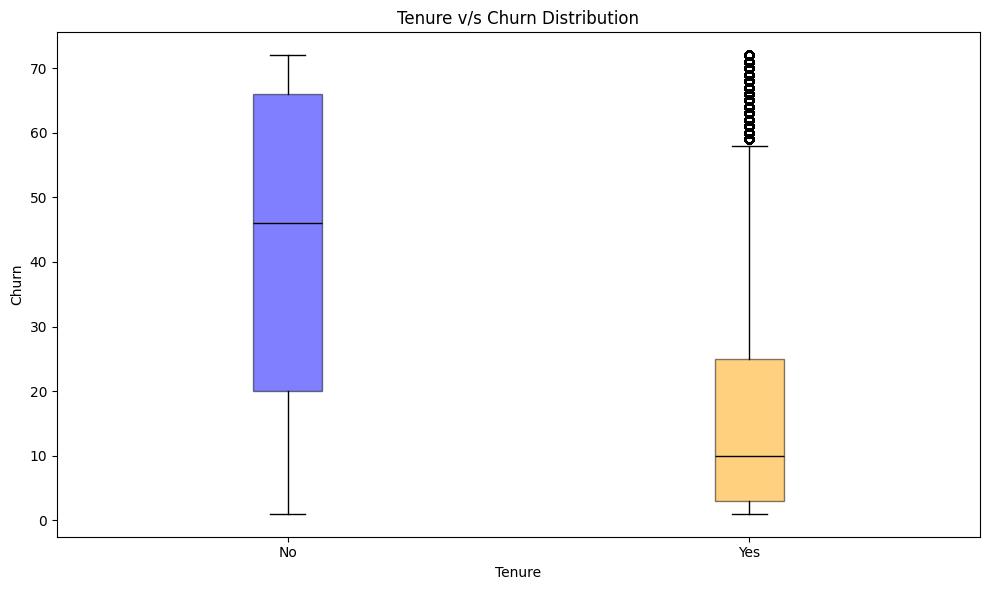

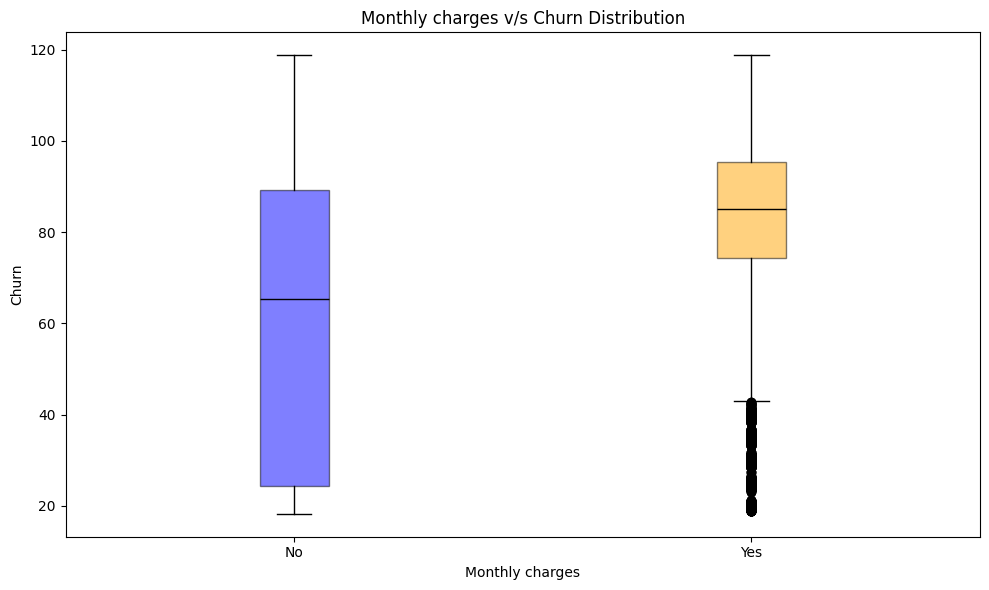

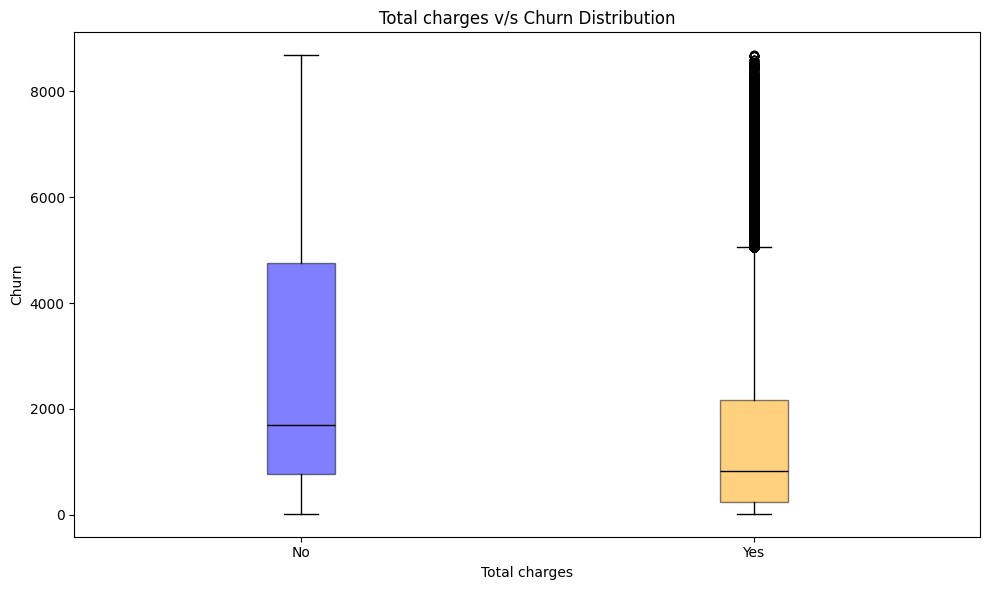

In [44]:
for col in numerical_columns:
    plot_box_by_target(
        feature = train_df[col],
        target = train_df['CHURN'],
        x_label = f"{col.replace('_', ' ').capitalize()}",
        y_label = 'Churn',
        title = f"{col.replace('_', ' ').capitalize()} v/s Churn Distribution",
        colors = ['blue', 'orange'],
        alpha = 0.5,
        fig_size = (10, 6)
    )

**`Observations - Bivariate Analysis for Numerical Columns`**
- Tenure
  - Non-churners have a median tenure of **~46 months** vs churners at only **~10 months**
    - **One of the strongest signals we've seen so far**.
  - Customers who stay longer are clearly more committed to the service, which aligns with the bimodal pattern we observed earlier.
  - Interesting outliers in the churner group at **70-72 months**. Even some very long-tenure customers eventually leave, possibly due to better competitor offers or price hikes.
- Monthly Charges
  - Churners are concentrated in the **high charges bracket (75-95)** with a very tight IQR, meaning customers who churn are almost exclusively high-paying customers.
  - Non-churners are spread across the full range, suggesting lower-paying customers tend to stay.
  - The outliers at the bottom of the churner group **(18-43)** are likely the basic plan, month-to-month contract customers we identified during the Bivariate Analysis of `CONTRACT` column.
- Total Charges
  - Churners have a notably lower median total charges **(~800)** vs non-churners **(~1800)**.
    - This is largely explained by `TENURE`, customers who churn leave early and naturally accumulate less total charges.
  - Total Charges is effectively a proxy for `TENURE`, confirms there could be multicollinearity between these two columns.

### Correlation Map

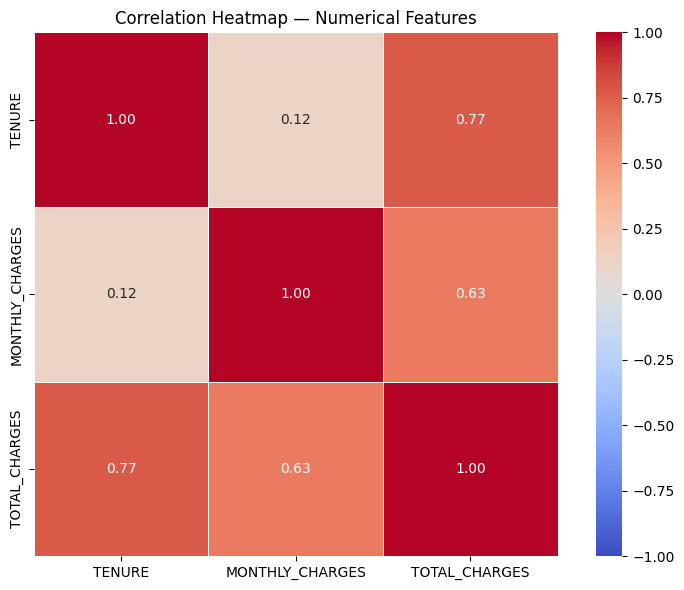

In [45]:
corr_matrix = train_df[numerical_columns].corr()

plt.figure(figsize = (8, 6))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    vmin = -1,
    vmax = 1,
    square = True,
    linewidths = 0.5
)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

**`Observations - Correlation Heatmap`**
- **TENURE vs TOTAL_CHARGES = 0.77**
  - **`Strong positive correlation.`**
  - Customers who stay longer naturally accumulate more total charges.
  - These two features carry overlapping information, confirming the multicollinearity concern flagged earlier.
  - Consider dropping `TOTAL_CHARGES` since `TENURE` is a more direct and stronger predictor of churn.
- **MONTHLY_CHARGES vs TOTAL_CHARGES = 0.63**
  - **`Moderate positive correlation.`**
  - Higher monthly bills lead to higher total charges over time. Expected and intuitive.
- **TENURE vs MONTHLY_CHARGES = 0.12**
  - `Very weak correlation.`
  - How long a customer stays has almost no relationship with how much they pay monthly. These two features are largely independent of each other.

**`Note:`** Tree-based models like XGBoost handle multicollinearity reasonably well, so this may not directly impact model performance. However, dropping `TOTAL_CHARGES` is still worth experimenting with during feature selection.

In [46]:
categorical_columns

array(['GENDER', 'PARTNER', 'DEPENDENTS', 'PHONE_SERVICE',
       'MULTIPLE_LINES', 'INTERNET_SERVICE', 'ONLINE_SECURITY',
       'ONLINE_BACKUP', 'DEVICE_PROTECTION', 'TECH_SUPPORT',
       'STREAMING_TV', 'STREAMING_MOVIES', 'CONTRACT',
       'PAPERLESS_BILLING', 'PAYMENT_METHOD', 'SENIOR_CITIZEN'],
      dtype=object)

In [ ]:
ADDITIONAL_SERVICE = [
    'ONLINE_SECURITY', 'ONLINE_BACKUP', 'DEVICE_PROTECTION', 'TECH_SUPPORT'
]